# Importing libraries and data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data from the adjacent 'Data' directory
df = pd.read_csv('../Data/Sleep_health_and_lifestyle_dataset.csv')

print('Fist five rows')
df.head()


Fist five rows


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


# Observations

In [2]:
#Check the dataset's data types, the number of records, column names and missing values
print('info')
df.info()

#Check summary statistics
print("\ndescribe")
df.describe()

info
<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 38.1 KB

describe


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


## Hypotheses

1. Stress directly decreases the sleep quality by making it harder to fall asleep, due to high heart rate and anxiety<br>
2. Stress degrades sleep quality (the sleep becomes superficial), while  the sleep quantity may remain unchanged or even increase, because the body tries to compensate for fatigue by staying in bed longer <br>


### Initial observations
To investigate our hypotheses, we grouped the dataset by `Stress Level` and calculated the mean values for all numberic fields. <br>
This allows us to observe general trends and see how changes in stress correspond to sleep metrics and demographics. <br>

In [39]:
agr_data_by_stress_level = df.groupby(by='Stress Level').mean(numeric_only=True)
agr_data_by_stress_level = agr_data_by_stress_level.drop(columns='Person ID')
agr_data_by_stress_level

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Heart Rate,Daily Steps
Stress Level,,,,,,
3,54.169014,8.226761,8.971831,54.718310,67.098592,6132.394366
4,39.900000,7.030000,7.671429,55.785714,66.828571,6422.857143
5,40.313433,7.483582,7.895522,74.253731,70.074627,7616.417910
6,33.065217,7.454348,7.000000,67.152174,70.717391,7363.043478
7,42.680000,6.468000,6.000000,43.840000,73.300000,5662.000000
8,39.742857,6.050000,5.857143,58.342857,74.100000,7605.714286


#### Key observations from the table:
- **Sleep duration trend:** As stress increases, there is a clear downward trend in sleep hours. The most significant drop is between stress levels 3 and 4.
- **The quality vs. quantity paradox:** Between stress levels 5 and 6, the average sleep duration remains almost identical (~7.45 hours), yet the subjective `Quality of Sleep` drops from 7.89 to 7.00. This provides early, indirect support for our second hypothesis.
- **Age and stress:** It is worth noting, the least stressed group (level 3) has the highest average age (~54 years), while the group with the lowest average age (~33 years) is found at stress level 6.

Text(0, 0.5, 'Average Quality of Sleep (4-9)')

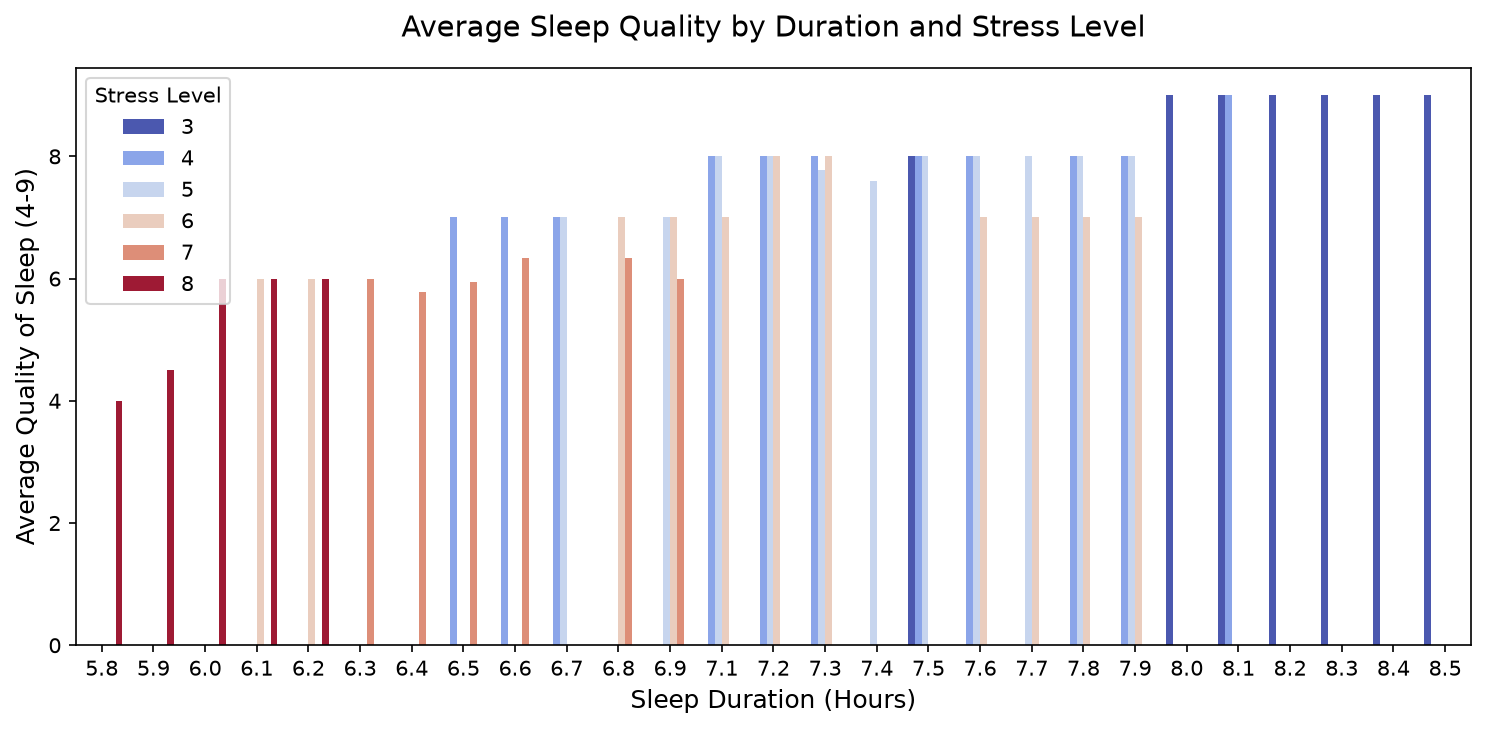

In [5]:
plt.figure(figsize=(12, 5), dpi=150)
sns.barplot(data = df, x='Sleep Duration', y ='Quality of Sleep', hue = 'Stress Level', palette='coolwarm', estimator=np.mean, errorbar=None)

plt.title('Average Sleep Quality by Duration and Stress Level', fontsize=14, pad=15)
plt.xlabel('Sleep Duration (Hours)', fontsize=12)
plt.ylabel('Average Quality of Sleep (4-9)', fontsize=12)

#### Key observations from the barplot:
While the aggregated table showed general trends, this bar chart reveals the distribution of the data and provides us with new observations: <br>

- **The volatility of stress level 6:** The chart highlights that people who estimated their stress level at '6' have a sleep duration from just over 6 hours (6.1) to almost 8 hours (7.9). This might mean that, regardless of how much extra time they spend in bed, their subjective `Quality of Sleep` never exceeds 8. This strongly strengthens **Hypothesis #2** (the sleep remains superficial and fails to recover efficiency).

- **The critical threshold (sleep < 6h):** Interestingly, individuals who sleep less than 6 hours exclusively estimated their stress level at '8', which is the maximum value in this dataset.

- **Data limitation note:** It is important to highlight a dataset limitation. The exact metrics and boundaries of the `Stress Level` scale are not fully documented (we only observe values from 3 to 8). The same situation applies to `Quality of Sleep`, where we only observe values between 4 and 9.


### Investigation of the correletion between `Stress Level` and `Heart Rate` (Hypothesis #1) 
To investigate our first hypothesis we'll take the following steps: <br>
1. Check for a correlation between `Stress Level` and `Heart Rate`
2. Check for a correlation between `Heart Rate` and both `Sleep Duration` and `Quality of Sleep`
3. Check for a correlation between `Stress Level` and `Sleep Disorder`

This will help us understand whether there is a physiological mechanism behind stress and see if a high heart rate impacts sleep quality and duration.

In [16]:
df[['Sleep Duration', 'Stress Level','Quality of Sleep','Heart Rate','Physical Activity Level','Daily Steps','Age']].corr()

,Sleep Duration,Stress Level,Quality of Sleep,Heart Rate,Physical Activity Level,Daily Steps,Age
Sleep Duration,1.000000,-0.811023,0.883213,-0.516455,0.212360,-0.039533,0.344709
Stress Level,-0.811023,1.000000,-0.898752,0.670026,-0.034134,0.186829,-0.422344
Quality of Sleep,0.883213,-0.898752,1.000000,-0.659865,0.192896,0.016791,0.473734
Heart Rate,-0.516455,0.670026,-0.659865,1.000000,0.136971,-0.030309,-0.225606
Physical Activity Level,0.212360,-0.034134,0.192896,0.136971,1.000000,0.772723,0.178993
Daily Steps,-0.039533,0.186829,0.016791,-0.030309,0.772723,1.000000,0.057973
Age,0.344709,-0.422344,0.473734,-0.225606,0.178993,0.057973,1.000000


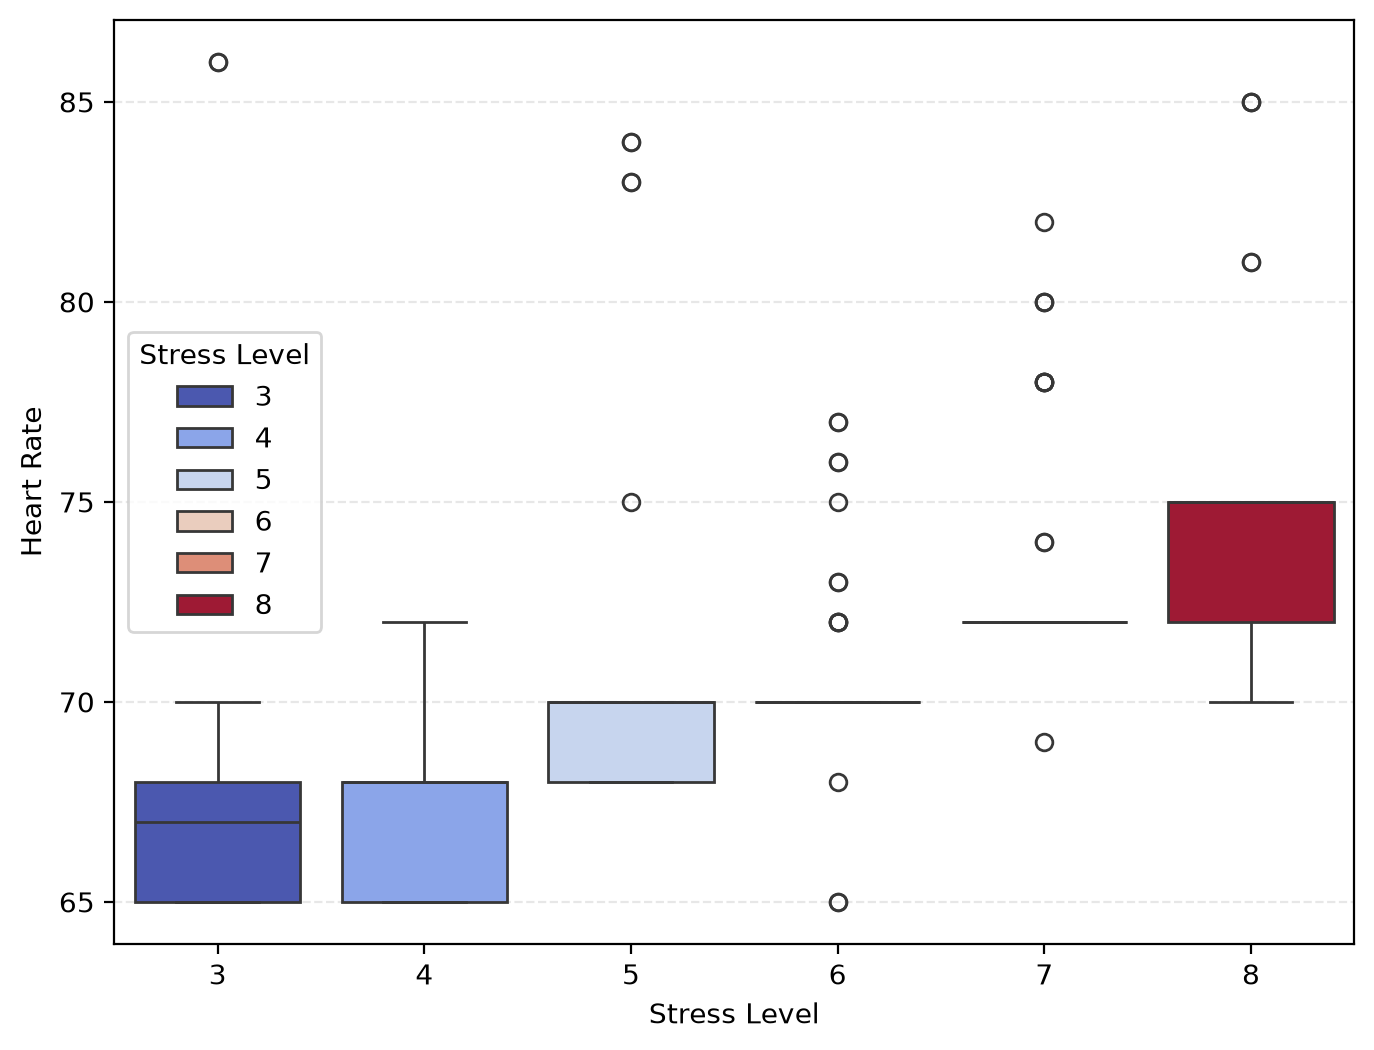

In [22]:
plt.figure(figsize=(8,6), dpi=200)
sns.boxplot(data=df, x='Stress Level', y = 'Heart Rate', hue = 'Stress Level', palette='coolwarm')
plt.grid(True, linestyle='--', alpha=0.3, axis='y')